# E‑commerce Fraud Data – EDA, Preprocessing & Feature Engineering
**Task 1 – 10 Academy Fraud Detection Challenge**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE  # <-- comment out

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [33]:
fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
print("Shape:", fraud.shape)
fraud.head()

Shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [34]:
print(fraud.isnull().sum())
print(f"Duplicates: {fraud.duplicated().sum()}")

fraud['signup_time'] = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time'])

fraud.dtypes

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Duplicates: 0


user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object

In [35]:
fraud['class'].value_counts(normalize=True)

class
0    0.906354
1    0.093646
Name: proportion, dtype: float64

In [36]:
fraud[['purchase_value', 'age']].describe()

,purchase_value,age
count,151112.000000,151112.000000
mean,36.935372,33.140704
std,18.322762,8.617733
min,9.000000,18.000000
25%,22.000000,27.000000
50%,35.000000,33.000000
75%,49.000000,39.000000
max,154.000000,76.000000


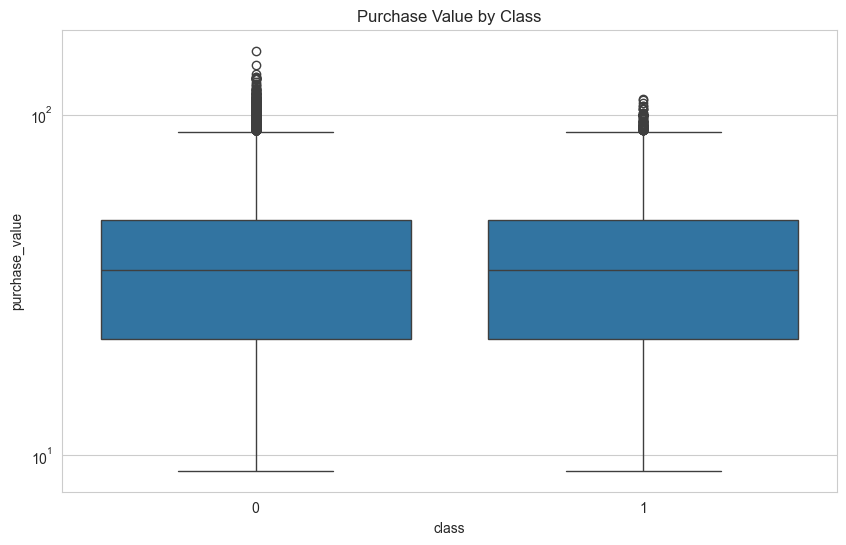

In [37]:
sns.boxplot(x='class', y='purchase_value', data=fraud)
plt.yscale('log')
plt.title('Purchase Value by Class')
plt.show()

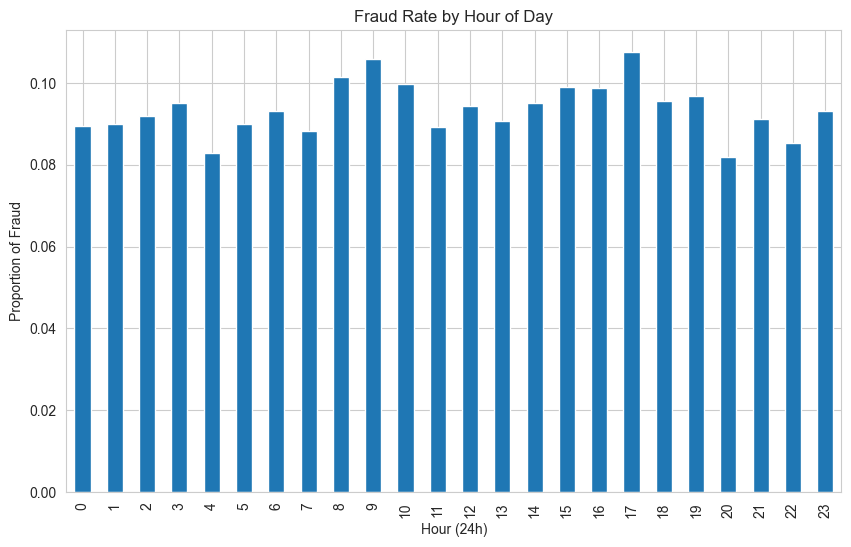

In [38]:
fraud['hour'] = fraud['purchase_time'].dt.hour
fraud_by_hour = fraud.groupby('hour')['class'].mean()
fraud_by_hour.plot(kind='bar')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour (24h)')
plt.ylabel('Proportion of Fraud')
plt.show()

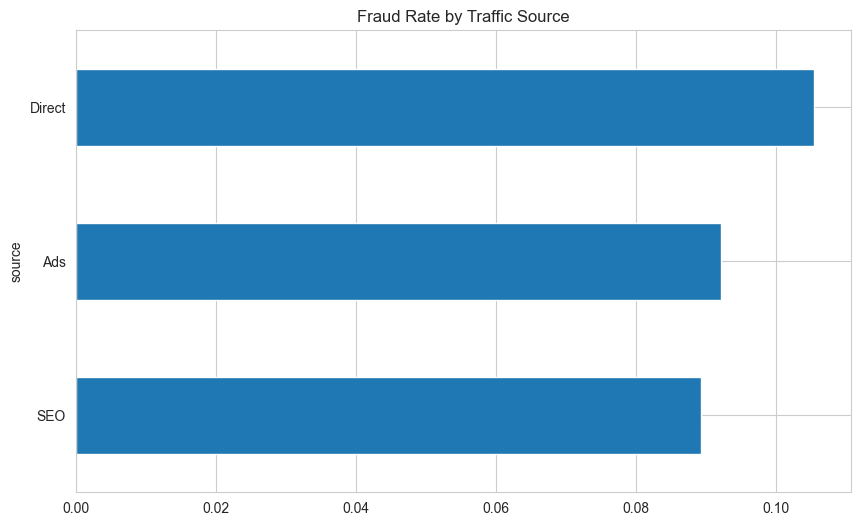

In [39]:
fraud.groupby('source')['class'].mean().sort_values().plot(kind='barh')
plt.title('Fraud Rate by Traffic Source')
plt.show()

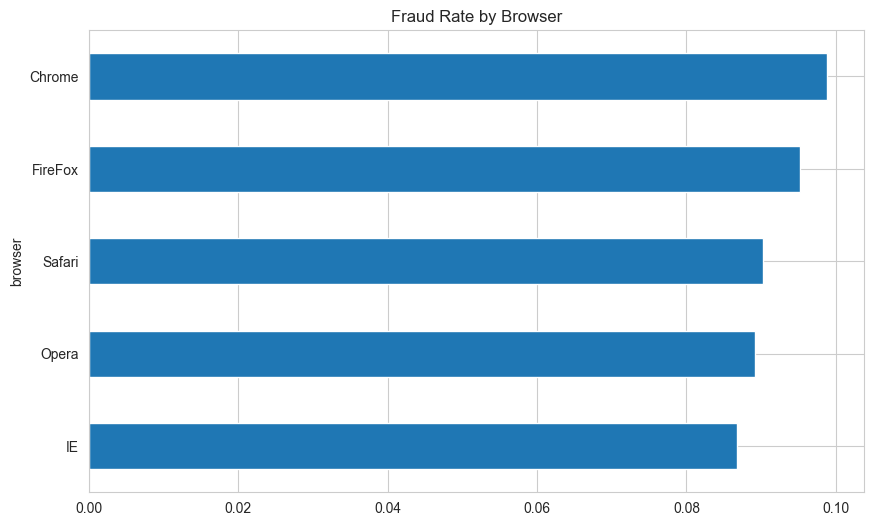

In [40]:
fraud.groupby('browser')['class'].mean().sort_values().plot(kind='barh')
plt.title('Fraud Rate by Browser')
plt.show()

In [41]:
def ip_to_int(ip):
    parts = ip.split('.')
    return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])

In [42]:
ip_ranges = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

ip_ranges['lower_int'] = ip_ranges['lower_bound_ip_address'].astype(int)
ip_ranges['upper_int'] = ip_ranges['upper_bound_ip_address'].astype(int)  # already int64

ip_ranges = ip_ranges.sort_values('lower_int')


ip_ranges.head()

,lower_bound_ip_address,upper_bound_ip_address,country,lower_int,upper_int
0,16777216.0,16777471,Australia,16777216,16777471
1,16777472.0,16777727,China,16777472,16777727
2,16777728.0,16778239,China,16777728,16778239
3,16778240.0,16779263,Australia,16778240,16779263
4,16779264.0,16781311,China,16779264,16781311


In [ ]:
fraud['ip_int'] = fraud['ip_address'].astype(int)

fraud = fraud.sort_values('ip_int')
ip_ranges = ip_ranges.sort_values('lower_int')

fraud = pd.merge_asof(fraud, ip_ranges, left_on='ip_int', right_on='lower_int', direction='backward')

fraud = fraud[fraud['ip_int'] <= fraud['upper_int']].copy()


fraud['country'].value_counts().head(10)

country
United States        58049
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Italy                 1944
Name: count, dtype: int64